In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

### Create a fake dataset 

This dataset is a simple polynomial regression problem with a small it of noise

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

### Create expressions

1. The first expression is a rolling mean of the species count for visualization purposes.
2. The second expression calculates the error of the species count rolling mean compared to the current species count.
3. The third expression calculates a threshold for the NEAT distance based on the last species threshold. 

The third threshold is essentially equivalent to something like

```python
def species_threshold(target_species: int) -> rd.Expr:
    GAIN = 0.3
    target = float(max(target_species, 1))

    count_error = (
        rd.Expr.select("count.species").rolling(target_species).mean() - target
    ) / target

    step = (count_error * GAIN + 1.0).clamp(0.8, 1.5)
    prev = rd.Expr.select("species.threshold").last()

    result = (prev * step).clamp(0.005, 2.0)
    return result
```

In [ ]:
target_species = 4

rolling_species_count = rd.Expr.select("count.species").rolling(25).mean()


index = rd.Expr.select("index")
count = rd.Expr.select("count.species") - target_species


correction = (
    rd.Expr.when(index < 2)
    .then(0.2)
    .otherwise(
        rd.Expr.when(count < 0)
        .then(rd.Expr.select("species.threshold") - 0.01)
        .otherwise(
            rd.Expr.when(count > 0)
            .then(rd.Expr.select("species.threshold") + 0.01)
            .otherwise(rd.Expr.select("species.threshold"))
        )
    )
)

### Create the engine

This engine evolves `rd.Graph`s to fit the polynomial regression problem. The vertices of the graph are only allowed to use addition, multiplication, and constants. The engine also tracks the species count and species threshold as metrics, and uses the NEAT distance as a diversity metric.

In [ ]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(rd.NeatDistance(), correction)
    .metrics(
        species_rolling=rolling_species_count,
        correction=correction,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-06-09T00:35:45.640478Z  INFO Epoch 1    | Score:   2.0038 | Time: 265.00µs
2026-06-09T00:35:45.640635Z  INFO Epoch 2    | Score:   1.6821 | Time: 368.29µs
2026-06-09T00:35:45.640780Z  INFO Epoch 3    | Score:   1.6821 | Time: 474.33µs
2026-06-09T00:35:45.640918Z  INFO Epoch 4    | Score:   1.6821 | Time: 574.92µs
2026-06-09T00:35:45.641050Z  INFO Epoch 5    | Score:   1.6821 | Time: 668.54µs
2026-06-09T00:35:45.641179Z  INFO Epoch 6    | Score:   1.6821 | Time: 767.00µs
2026-06-09T00:35:45.641293Z  INFO Epoch 7    | Score:   1.6821 | Time: 853.62µs
2026-06-09T00:35:45.641402Z  INFO Epoch 8    | Score:   1.6821 | Time: 931.08µs
2026-06-09T00:35:45.641508Z  INFO Epoch 9    | Score:   1.6821 | Time: 1.01ms
2026-06-09T00:35:45.641611Z  INFO Epoch 10   | Score:   1.6821 | Time: 1.08ms
2026-06-09T00:35:45.641712Z  INFO Epoch 11   | Score:   1.6821 | Time: 1.16ms
2026-06-09T00:35:45.641813Z  INFO Epoch 12   | Score:   1.6821 | Time: 1.23ms
2026-06-09T00:35:45.641908Z  INFO Epoch 13   | S

### Metrics

Using the `rd.MetricCollector` we can aggregate the metrics for the whole engine's run and visualize the metrics we want to track here once the engine has finished. In this case we only want to see our three expressions, but we could also see any `rd.Metric` that the engine tracks - refer to the docs for more details.

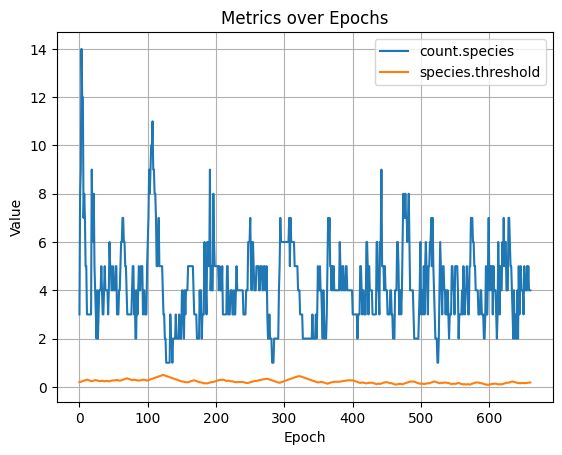

In [5]:
collector.plot(
    "count.species",
    "species.threshold",
)  # , "species_rolling", "species_count_error", "err")
# collector.plot("err")

In [6]:
df = collector.to_polars()
df.filter(pl.col("name") == "count.species").tail(20)
# df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.species""",4.0,2671.0,4.160436,1.716432,2.946139,2.163103,1.0,14.0,642,null,null,null,null,null,null,641,1,"[""species"", ""statistic""]"
"""count.species""",2.0,2673.0,4.157076,1.71721,2.948809,2.160458,1.0,14.0,643,null,null,null,null,null,null,642,1,"[""species"", ""statistic""]"
"""count.species""",5.0,2678.0,4.158385,1.716195,2.945326,2.15893,1.0,14.0,644,null,null,null,null,null,null,643,1,"[""species"", ""statistic""]"
"""count.species""",3.0,2681.0,4.156589,1.715469,2.942833,2.164706,1.0,14.0,645,null,null,null,null,null,null,644,1,"[""species"", ""statistic""]"
"""count.species""",4.0,2685.0,4.156347,1.714149,2.938308,2.169701,1.0,14.0,646,null,null,null,null,null,null,645,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""count.species""",4.0,2731.0,4.156773,1.70135,2.894592,2.2061,1.0,14.0,657,null,null,null,null,null,null,656,1,"[""species"", ""statistic""]"
"""count.species""",5.0,2736.0,4.158055,1.700373,2.891267,2.204588,1.0,14.0,658,null,null,null,null,null,null,657,1,"[""species"", ""statistic""]"
"""count.species""",4.0,2740.0,4.157815,1.699091,2.886911,2.209654,1.0,14.0,659,null,null,null,null,null,null,658,1,"[""species"", ""statistic""]"


In [7]:
df.filter(pl.col("name") == "err").tail(20)

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""err""",0.0,25.75,0.040109,0.429108,0.184134,0.0,-0.75,2.5,642,null,null,null,null,null,null,641,1,"[""statistic"", ""expr""]"
"""err""",-0.5,25.25,0.039269,0.429302,0.184301,0.0,-0.75,2.5,643,null,null,null,null,null,null,642,1,"[""statistic"", ""expr""]"
"""err""",0.25,25.5,0.039596,0.429049,0.184083,0.0,-0.75,2.5,644,null,null,null,null,null,null,643,1,"[""statistic"", ""expr""]"
"""err""",-0.25,25.25,0.039147,0.428867,0.183927,0.0,-0.75,2.5,645,null,null,null,null,null,null,644,1,"[""statistic"", ""expr""]"
"""err""",0.0,25.25,0.039087,0.428537,0.183644,0.0,-0.75,2.5,646,null,null,null,null,null,null,645,1,"[""statistic"", ""expr""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""err""",0.0,25.75,0.039193,0.425338,0.180912,0.0,-0.75,2.5,657,null,null,null,null,null,null,656,1,"[""statistic"", ""expr""]"
"""err""",0.25,26.0,0.039514,0.425093,0.180704,0.0,-0.75,2.5,658,null,null,null,null,null,null,657,1,"[""statistic"", ""expr""]"
"""err""",0.0,26.0,0.039454,0.424773,0.180432,0.0,-0.75,2.5,659,null,null,null,null,null,null,658,1,"[""statistic"", ""expr""]"


In [8]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

661


660